## Importing packages


In [1]:
import os
import cv2
import glob
import time
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
from PIL import Image
from tqdm import tqdm
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.utils import resample
from torchvision import transforms
from torch.utils.data import Dataset
from scipy.ndimage import gaussian_filter1d
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

#### Constant


In [ ]:
# CONSTANT
BASE_DIR = '/home/codezerro/Desktop/Follow-Line-Combine-Dataset'
TEST_DATA_CSV = "test.csv"
TRAIN_DATA_CSV = "train.csv"
PROCESSED_DIR = "PROCESSED_FILES_AND_IMAGE_OUTPUT_DIR"
IMG_HEIGHT = 240



# Paths
train_path = os.path.join(BASE_DIR, TRAIN_DATA_CSV)
test_path = os.path.join(BASE_DIR, TEST_DATA_CSV)

#### Load datasets


In [3]:
# Load datasets
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

In [4]:
# DF Head
train_df.head(3)

,image,v,w
0,train_images_part_03/montreal_circuit-17544009...,6.4,-0.10833
1,train_images_part_07/montreal_circuit-17544009...,6.4,-0.10833
2,train_images_part_02/montreal_circuit-17544009...,6.4,-0.03066


In [5]:
# DF Describe
train_df.describe()

# you can save the dataset if you want
train_df.to_csv(os.path.join(PROCESSED_DIR,'train.csv'),index=False)
test_df.to_csv(os.path.join(PROCESSED_DIR,'test.csv'),index=False)

In [6]:
# DF Describe of linear velocity (v)
train_df['v'].describe()

count    62786.000000
mean         5.230639
std          1.176530
min          4.000000
25%          4.000000
50%          5.080000
75%          6.400000
max          7.000000
Name: v, dtype: float64

In [7]:
# DF Describe of angular velocity (w)
train_df['w'].describe()

count    62786.000000
mean        -0.004446
std          0.392995
min         -2.500000
25%         -0.053740
50%          0.000440
75%          0.051400
max          2.500000
Name: w, dtype: float64

## 1. Visualize indivisual circuits dataset


In [8]:
# Categorize angular velocity (w) into 5 categories
def categorize_w(w):
    if w < -1.0:
        return "sharp_right"
    elif w < -0.05:
        return "right"
    elif w <= 0.05:
        return "straight"
    elif w <= 1.0:
        return "left"
    else:
        return "sharp_left"

In [9]:
train_df["w_category"] = train_df["w"].apply(categorize_w)

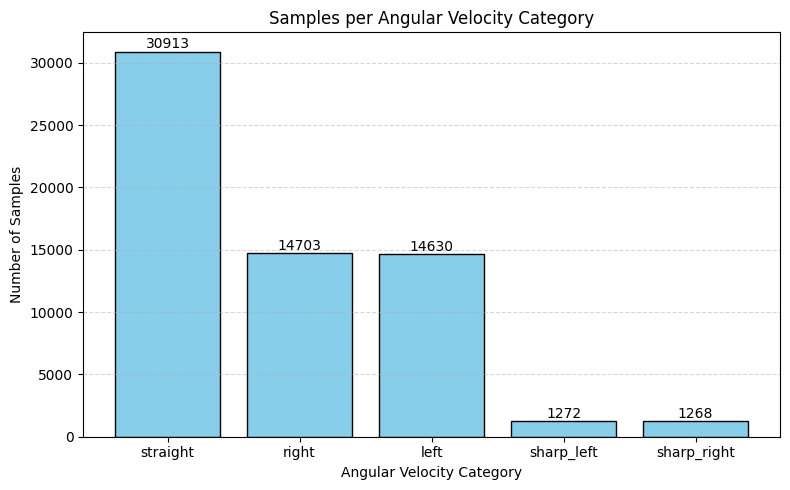

In [10]:
category_counts = train_df['w_category'].value_counts()

# Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(category_counts.index, category_counts.values, color='skyblue', edgecolor='black')

# Add counts above bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 10, int(yval), ha='center', va='bottom', fontsize=10)

# Labels and title
plt.title(f"Samples per Angular Velocity Category")
plt.xlabel("Angular Velocity Category")
plt.ylabel("Number of Samples")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig(f"{PROCESSED_DIR}/angular_velocity_category.png")
plt.show()

## 2. Balanced Dataset


In [11]:
TARGET_COUNT = 20000

balanced_classes = []

# Process each class
for category in train_df['w_category'].unique():
    class_df = train_df[train_df['w_category'] == category]

    if len(class_df) > TARGET_COUNT:
        # Downsample
        class_balanced = class_df.sample(n=TARGET_COUNT, random_state=42)
    else:
        # Oversample with replacement
        class_balanced = resample(class_df, replace=True, n_samples=TARGET_COUNT, random_state=42)

    balanced_classes.append(class_balanced)


# Combine all balanced classes
df_balanced = pd.concat(balanced_classes).sample(frac=1, random_state=42).reset_index(drop=True)

df_balanced.to_csv(os.path.join(PROCESSED_DIR,f'balanced_train.csv'),index=False)

## 3. Image Processing


In [12]:
# Directory list
images_dir_list = [
    "train_images_part_01",
    "train_images_part_02",
    "train_images_part_03",
    "train_images_part_04",
    "train_images_part_05",
    "train_images_part_06",
    "train_images_part_07",
]

In [13]:
# Create folder on PROCESSED DIR
for img_dir in images_dir_list:
    os.makedirs(os.path.join(PROCESSED_DIR,img_dir),exist_ok=True)

In [14]:
def imageProcessing(img_dir,image_name)->bool:
    
    # CREATE FOLDER/CHECK according the current folder name
    os.makedirs(os.path.join(PROCESSED_DIR,img_dir),exist_ok=True)

    # Transform to tensor
    to_tensor = transforms.ToTensor()  # Converts PIL to [C,H,W] FloatTensor in [0,1]
    to_pil = transforms.ToPILImage()   # For visualization or debug

    # image path
    path = os.path.join(BASE_DIR,image_name)
    
    try:
        # Load image with PIL and convert to RGB
        img = Image.open(path).convert('RGB')

        # To tensor and move to GPU
        tensor = to_tensor(img).unsqueeze(0).cuda()  # Shape: [1, 3, H, W]

        # Crop last 240 rows
        cropped_tensor = tensor[:, :, -IMG_HEIGHT:, :]  # Shape: [1, 3, 240, W]

        # Move to CPU and convert to numpy image (H, W, C) in uint8
        cropped_img_np = (cropped_tensor.squeeze(0).permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)

        # Save using OpenCV
        filename = os.path.basename(path)
        # save to current dir folder in processed path
        save_path = os.path.join(PROCESSED_DIR,img_dir,filename)
        
            
        cv2.imwrite(save_path, cv2.cvtColor(cropped_img_np, cv2.COLOR_RGB2BGR))

        return True
    except Exception as e:
        print(f"Error processing {path}: {e}")
        return False

In [15]:
# Instead copy all the image, we only apply proccessing on the balanced_tran.csv
start_time = time.time()
train_success_cnt = 0
train_error_cnt = 0

test_success_cnt = 0
test_error_cnt = 0

# for the train dataset
for image_name in train_df['image']:
    # print(image_name)
    for img_dir in images_dir_list:
        if image_name.startswith(img_dir+"/"):
            if imageProcessing(img_dir,image_name):
                train_success_cnt += 1
            else: train_error_cnt += 1


# for the test dataset
for image_name in test_df['image']:
    if imageProcessing("test_images",image_name):
        test_success_cnt += 1
    else: test_error_cnt += 1


# end time
end_time = time.time()
elapsed = end_time - start_time

print(f"Train Images successed to process {train_success_cnt} images.")
print(f"Train Images Failed to process {train_error_cnt} images.")

print(f"Test Images successed to process {test_success_cnt} images.")
print(f"Test Images Failed to process {test_error_cnt} images.")

print(f"Elapsed time: {elapsed:.2f} seconds")

Train Images successed to process 62786 images.
Train Images Failed to process 0 images.
Test Images successed to process 9755 images.
Test Images Failed to process 0 images.
Elapsed time: 559.25 seconds


## Train Model using NVIDIA PILOTNET


In [16]:
class FollowLineDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        self.annotations = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

        # Optional: Validate required columns
        expected_columns = ['image', 'v', 'w']
        if len(self.annotations.columns) < 3:
            raise ValueError(f"CSV must have at least 3 columns: {expected_columns}")
        
    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.item()  # support Tensor indices
    
        # Get image name and velocity values
        img_name = self.annotations.iloc[idx, 0]
        linear_velocity = float(self.annotations.iloc[idx, 1])
        angular_velocity = float(self.annotations.iloc[idx, 2])
    
        # Optional: round to desired precision (e.g., 3 decimal places)
        linear_velocity = round(linear_velocity, 3)
        angular_velocity = round(angular_velocity, 3)
    
        # Load image
        img_path = os.path.join(self.root_dir, img_name)
        try:
            image = Image.open(img_path).convert("RGB")
        except FileNotFoundError:
            raise FileNotFoundError(f"Image not found: {img_path}")
    
        if self.transform:
            image = self.transform(image)
    
        velocities = torch.tensor([linear_velocity, angular_velocity], dtype=torch.float32)
        return image, velocities

In [17]:
# PilotNet Neural Network
class PilotNet(nn.Module):
    def __init__(self):
        super(PilotNet, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 24, kernel_size=5, stride=2),
            nn.ReLU(),
            nn.Conv2d(24, 36, kernel_size=5, stride=2),
            nn.ReLU(),
            nn.Conv2d(36, 48, kernel_size=5, stride=2),
            nn.ReLU(),
            nn.Conv2d(48, 64, kernel_size=3),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3),
            nn.ReLU()
        )
        # Dynamically calculate flattened feature size
        with torch.no_grad():
            dummy_input = torch.zeros(1, 3, 240, 640)
            dummy_output = self.features(dummy_input)
            self.flattened_size = dummy_output.view(1, -1).shape[1]

        self.classifier = nn.Sequential(
            nn.Linear(self.flattened_size, 100),
            nn.ReLU(),
            nn.Linear(100, 50),
            nn.ReLU(),
            nn.Linear(50, 10),
            nn.ReLU(),
            nn.Linear(10, 2)  # Output: [v, w]
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

In [18]:
# Configuration
BATCH_SIZE = 32
LEARNING_RATE = 1e-4
IMAGE_SHAPE = (3, 240, 640)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using DEVICE: {DEVICE}")

Using DEVICE: cuda


### Train the model


In [21]:
# TRANSFORM AND LOAD DATASET
transform = transforms.Compose([
    transforms.Resize((240, 640)),
    transforms.ToTensor(),
])

train_dataset = FollowLineDataset(os.path.join(PROCESSED_DIR,'balanced_train.csv'),PROCESSED_DIR, transform=transform)
test_dataset = FollowLineDataset(os.path.join(PROCESSED_DIR,"test.csv"),PROCESSED_DIR, transform=transform)

train_size = len(train_dataset)
test_size = len(test_dataset)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

In [22]:
# INTIALIZE MODEL AND ADD OPTIMIZER
model = PilotNet().to(DEVICE)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

## TRAIN AND TEST


In [23]:
start_time = time.time()
NUM_EPOCHS = 10

# ========================================== TRAIN AND TEST ==========================================
train_losses = []
test_losses = []

for epoch in range(NUM_EPOCHS):
    model.train()
    total_train_loss = 0.0
    for images, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]"):
        images, targets = images.to(DEVICE), targets.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item() * images.size(0)
    
    avg_train_loss = total_train_loss / len(train_loader.dataset)
    train_losses.append(avg_train_loss)

    model.eval()
    total_test_loss = 0.0
    with torch.no_grad():
        for images, targets in tqdm(test_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Test]"):
            images, targets = images.to(DEVICE), targets.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, targets)
            total_test_loss += loss.item() * images.size(0)

    avg_test_loss = total_test_loss / len(test_loader.dataset)
    test_losses.append(avg_test_loss)

    print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Test Loss = {avg_test_loss:.4f}")


Epoch 1/10 [Test]: 100%|████████████████████████| 77/77 [00:26<00:00,  2.90it/s]


Epoch 1: Train Loss = 0.6204, Test Loss = 0.2565


Epoch 2/10 [Test]: 100%|████████████████████████| 77/77 [00:27<00:00,  2.84it/s]


Epoch 2: Train Loss = 0.1012, Test Loss = 0.1323


Epoch 3/10 [Test]: 100%|████████████████████████| 77/77 [00:25<00:00,  3.00it/s]


...

Epoch 8: Train Loss = 0.0437, Test Loss = 0.1534


Epoch 9/10 [Test]: 100%|████████████████████████| 77/77 [00:25<00:00,  3.02it/s]


Epoch 9: Train Loss = 0.0422, Test Loss = 0.1507


Epoch 10/10 [Test]: 100%|███████████████████████| 77/77 [00:25<00:00,  3.01it/s]

Epoch 10: Train Loss = 0.0388, Test Loss = 0.1490


### SAVE THE MODEL


In [24]:
# ========================================== SAVE MODEL ==========================================
dummy_input = torch.randn(1, 3, 240, 640).to(DEVICE)
onnx_path = f"{PROCESSED_DIR}/pilotnet_imitation_learning_simple_circuit_model.onnx"

torch.onnx.export(model, dummy_input, onnx_path,
                  input_names=['input'], output_names=['output'],
                  dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}},
                  opset_version=11)

### PLOTTING TEST-TRAIN LOSS CURVE


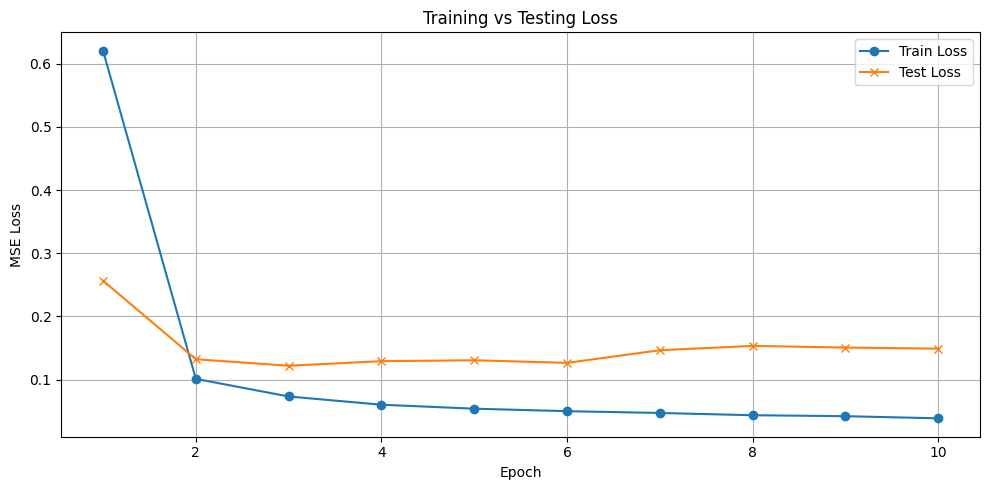

In [25]:
# ========================================== PLOTTING TEST-TRAIN LOSS CURVE ==========================================
# Plotting loss curve
plt.figure(figsize=(10, 5))
plt.plot(range(1, NUM_EPOCHS + 1), train_losses[:NUM_EPOCHS], label='Train Loss', marker='o')
plt.plot(range(1, NUM_EPOCHS + 1), test_losses[:NUM_EPOCHS], label=f"Test Loss", marker='x')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training vs Testing Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{PROCESSED_DIR}/loss_curve.png")
plt.show() 


### Evaluation Matrix


In [26]:
# ========================================== EVALUATION MATRICES ==========================================
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for images, targets in tqdm(test_loader, desc="Evaluating"):
        images, targets = images.to(DEVICE), targets.to(DEVICE)
        outputs = model(images)
        all_preds.append(outputs.cpu())
        all_targets.append(targets.cpu())

all_preds = torch.cat(all_preds).numpy()
all_targets = torch.cat(all_targets).numpy()

mse_total = mean_squared_error(all_targets, all_preds)
mae_total = mean_absolute_error(all_targets, all_preds)
r2_total = r2_score(all_targets, all_preds)

mse_v = mean_squared_error(all_targets[:, 0], all_preds[:, 0])
mae_v = mean_absolute_error(all_targets[:, 0], all_preds[:, 0])
r2_v = r2_score(all_targets[:, 0], all_preds[:, 0])

mse_w = mean_squared_error(all_targets[:, 1], all_preds[:, 1])
mae_w = mean_absolute_error(all_targets[:, 1], all_preds[:, 1])
r2_w = r2_score(all_targets[:, 1], all_preds[:, 1])


# save evaluation matrics results
with open(f"{PROCESSED_DIR}/evaluation_matrics.txt", "w") as f:
    f.write(f"--- Evaluation Metrics ---\n")
    f.write(f"Combined - MSE: {mse_total:.4f}, MAE: {mae_total:.4f}, R2: {r2_total:.4f}\n")
    f.write(f"Linear Velocity (v) - MSE: {mse_v:.4f}, MAE: {mae_v:.4f}, R2: {r2_v:.4f}\n")
    f.write(f"Angular Velocity (w) - MSE: {mse_w:.4f}, MAE: {mae_w:.4f}, R2: {r2_w:.4f}\n")
    f.write(f"\n\n\n")

Evaluating: 100%|███████████████████████████████| 77/77 [00:27<00:00,  2.75it/s]
